In [40]:
import os
import shutil
import random

random.seed(42)  # reproducible split
IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

# === EDIT THESE PATHS to match your machine ===
normal_dir = r"E:\research data\normal eye data"
retino_dir = r"E:\research data\retinopathy eye data"
base_dir   = r"E:\research data\dataset"   # where train/test will be created
# =============================================

train_dir = os.path.join(base_dir, 'train')
test_dir  = os.path.join(base_dir, 'test')

# Create clean folder structure
for sub in ['train/normal', 'train/retinopathy', 'test/normal', 'test/retinopathy']:
    path = os.path.join(base_dir, sub)
    os.makedirs(path, exist_ok=True)

def clear_folder(folder):
    """Remove all files/subfolders inside `folder` (keeps the folder itself)."""
    if not os.path.exists(folder):
        return
    for name in os.listdir(folder):
        path = os.path.join(folder, name)
        try:
            if os.path.isfile(path) or os.path.islink(path):
                os.unlink(path)
            elif os.path.isdir(path):
                shutil.rmtree(path)
        except Exception as e:
            print(f"WARNING: could not remove {path}: {e}")

# Clear destinations to avoid leftover duplicates from previous runs
clear_folder(os.path.join(train_dir, 'normal'))
clear_folder(os.path.join(test_dir, 'normal'))
clear_folder(os.path.join(train_dir, 'retinopathy'))
clear_folder(os.path.join(test_dir, 'retinopathy'))

def list_images(src_dir):
    return [f for f in os.listdir(src_dir)
            if f.lower().endswith(IMAGE_EXTS) and os.path.isfile(os.path.join(src_dir, f))]

def split_and_copy(src_dir, dst_train, dst_test, split_ratio=0.7, move_files=False):
    imgs = list_images(src_dir)
    imgs.sort()
    random.shuffle(imgs)
    n_train = int(len(imgs) * split_ratio)
    train_imgs = imgs[:n_train]
    test_imgs  = imgs[n_train:]
    # copy/move
    for fn in train_imgs:
        src = os.path.join(src_dir, fn)
        dst = os.path.join(dst_train, fn)
        if move_files:
            shutil.move(src, dst)
        else:
            shutil.copy2(src, dst)
    for fn in test_imgs:
        src = os.path.join(src_dir, fn)
        dst = os.path.join(dst_test, fn)
        if move_files:
            shutil.move(src, dst)
        else:
            shutil.copy2(src, dst)
    # return counts and intersection (should be empty)
    return len(train_imgs), len(test_imgs), set(train_imgs).intersection(set(test_imgs))

# Run split for both classes
train_normal, test_normal, inter_normal = split_and_copy(
    normal_dir,
    os.path.join(train_dir, 'normal'),
    os.path.join(test_dir, 'normal'),
    split_ratio=0.7,
    move_files=False  # False = keep original files; set True if you want to move
)

train_retino, test_retino, inter_retino = split_and_copy(
    retino_dir,
    os.path.join(train_dir, 'retinopathy'),
    os.path.join(test_dir, 'retinopathy'),
    split_ratio=0.7,
    move_files=False
)

# Sanity checks & summary
orig_normal = len(list_images(normal_dir))
orig_retino = len(list_images(retino_dir))
print("\n✅ Split complete — summary:\n")
print(f"Normal      -> Train: {train_normal}, Test: {test_normal}, Total(original): {orig_normal}")
print(f"Retinopathy -> Train: {train_retino}, Test: {test_retino}, Total(original): {orig_retino}")
print(f"TOTAL       -> Train: {train_normal + train_retino}, Test: {test_normal + test_retino}, Overall: {train_normal + test_normal + train_retino + test_retino}\n")

# Overlap checks
if inter_normal:
    print("⚠️ WARNING: the following filenames are in BOTH train and test (normal):")
    print(inter_normal)
else:
    print("No filename overlap between train/test for 'normal' class.")

if inter_retino:
    print("⚠️ WARNING: the following filenames are in BOTH train and test (retinopathy):")
    print(inter_retino)
else:
    print("No filename overlap between train/test for 'retinopathy' class.")

# Extra check: ensure no filename appears in train_normal and train_retino (very unlikely but safe)
train_normal_files = set(os.listdir(os.path.join(train_dir,'normal')))
train_retino_files = set(os.listdir(os.path.join(train_dir,'retinopathy')))
cross_train_inter = train_normal_files.intersection(train_retino_files)
if cross_train_inter:
    print("⚠️ WARNING: Some filenames appear in both train/normal and train/retinopathy (name collision):", cross_train_inter)

print("\nYou can now point Keras ImageDataGenerator at:")
print(f"  train: {os.path.join(base_dir, 'train')}")
print(f"  test : {os.path.join(base_dir, 'test')}")



✅ Split complete — summary:

Normal      -> Train: 751, Test: 323, Total(original): 1074
Retinopathy -> Train: 768, Test: 330, Total(original): 1098
TOTAL       -> Train: 1519, Test: 653, Overall: 2172

No filename overlap between train/test for 'normal' class.
No filename overlap between train/test for 'retinopathy' class.

You can now point Keras ImageDataGenerator at:
  train: E:\research data\dataset\train
  test : E:\research data\dataset\test


In [41]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r"E:\research data\dataset\train",
    target_size=(224,224),  # or the input size of your model
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    r"E:\research data\dataset\test",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)


Found 1519 images belonging to 2 classes.
Found 653 images belonging to 2 classes.


In [42]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [43]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)


Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.8690 - loss: 0.2838 - val_accuracy: 0.9602 - val_loss: 0.1749
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9816 - loss: 0.0789 - val_accuracy: 0.9832 - val_loss: 0.0586
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9928 - loss: 0.0271 - val_accuracy: 0.9923 - val_loss: 0.0530
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9961 - loss: 0.0148 - val_accuracy: 0.9893 - val_loss: 0.0552
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9974 - loss: 0.0164 - val_accuracy: 0.9939 - val_loss: 0.0461
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9980 - loss: 0.0082 - val_accuracy: 0.9939 - val_loss: 0.0434
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9993 - loss: 0.0078 - val_accuracy: 0.9939 - val_loss: 0.0483
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9980 - loss: 0.0062 - val_accuracy: 0.9969 - val_loss

In [44]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")


21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 547ms/step - accuracy: 0.9877 - loss: 0.0599
Test Accuracy: 98.77%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


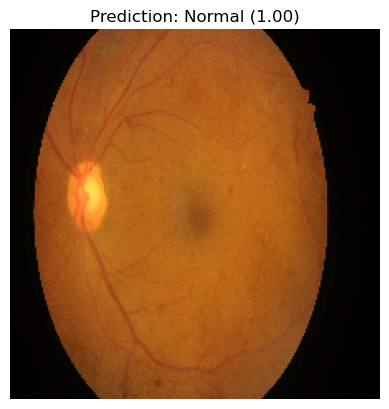

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


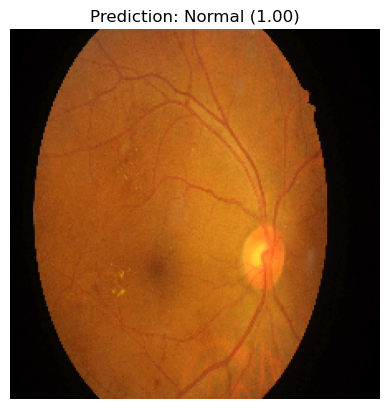

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


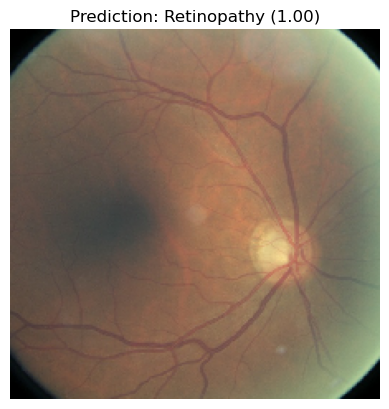

('Retinopathy', 0.9999988)

In [46]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_eye_image(img_path, model):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Prediction
    pred = model.predict(img_array)[0][0]
    label = "Retinopathy" if pred >= 0.5 else "Normal"
    probability = pred if pred >= 0.5 else 1-pred
    
    # Show image with prediction
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {label} ({probability:.2f})")
    plt.show()
    
    return label, probability

# Example
predict_eye_image(r"C:\Users\Trupti\OneDrive\Desktop\Eye images\IDRiD_008test.jpg", model)
predict_eye_image(r"C:\Users\Trupti\OneDrive\Desktop\Eye images\IDRiD_020test.jpg", model)
predict_eye_image(r"E:\research data\retinopathy eye data\1000_left.jpeg", model)
